# Notebook Objective

The objective of this notebook is to explore the credit card transaction dataset to identify patterns, trends, anomalies, and relationships between variables. The analysis aims to answer key business questions, understand the characteristics of fraudulent transactions, and generate insights that support data-driven decision-making.

## Data Loading

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("../data/processed/creditcard_clean.csv")
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


## 1. Transaction Amount Analysis

### Business Questions

- How are transaction amounts distributed?
- Are there any unusual or extreme transaction amounts?

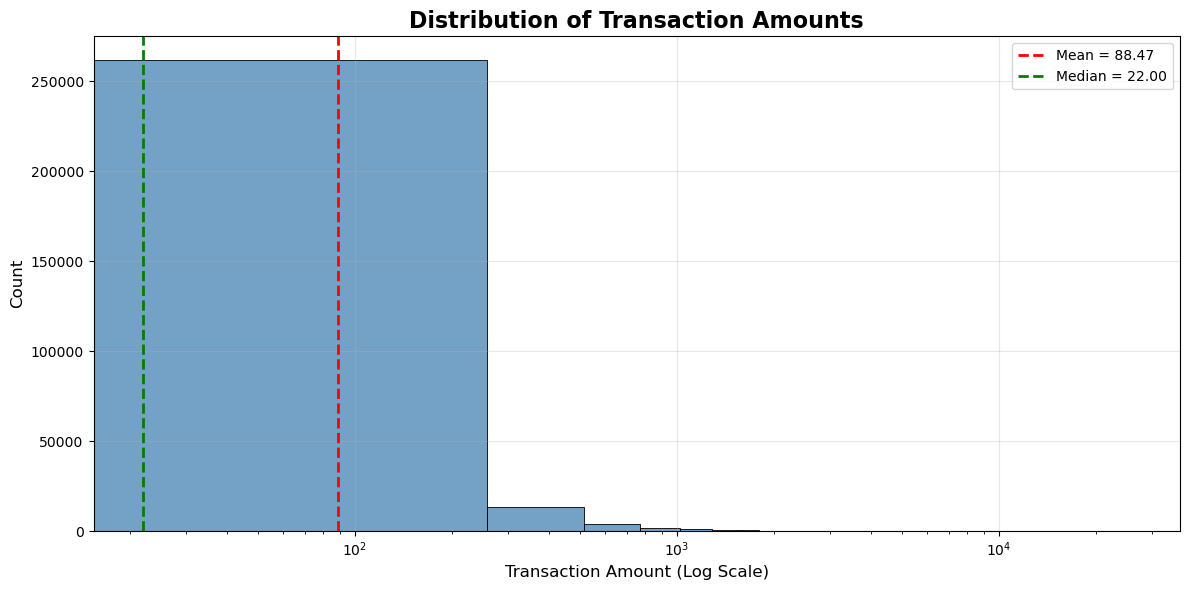

In [3]:
plt.figure(figsize=(12,6))

sns.histplot(
    data=df,
    x="Amount",
    bins=100,
    color="steelblue"
)

plt.xscale("log")

plt.axvline(df["Amount"].mean(),
            color="red",
            linestyle="--",
            linewidth=2,
            label=f"Mean = {df['Amount'].mean():.2f}")

plt.axvline(df["Amount"].median(),
            color="green",
            linestyle="--",
            linewidth=2,
            label=f"Median = {df['Amount'].median():.2f}")

plt.title("Distribution of Transaction Amounts", fontsize=16, weight="bold")
plt.xlabel("Transaction Amount (Log Scale)", fontsize=12)
plt.ylabel("Count", fontsize=12)

plt.grid(alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

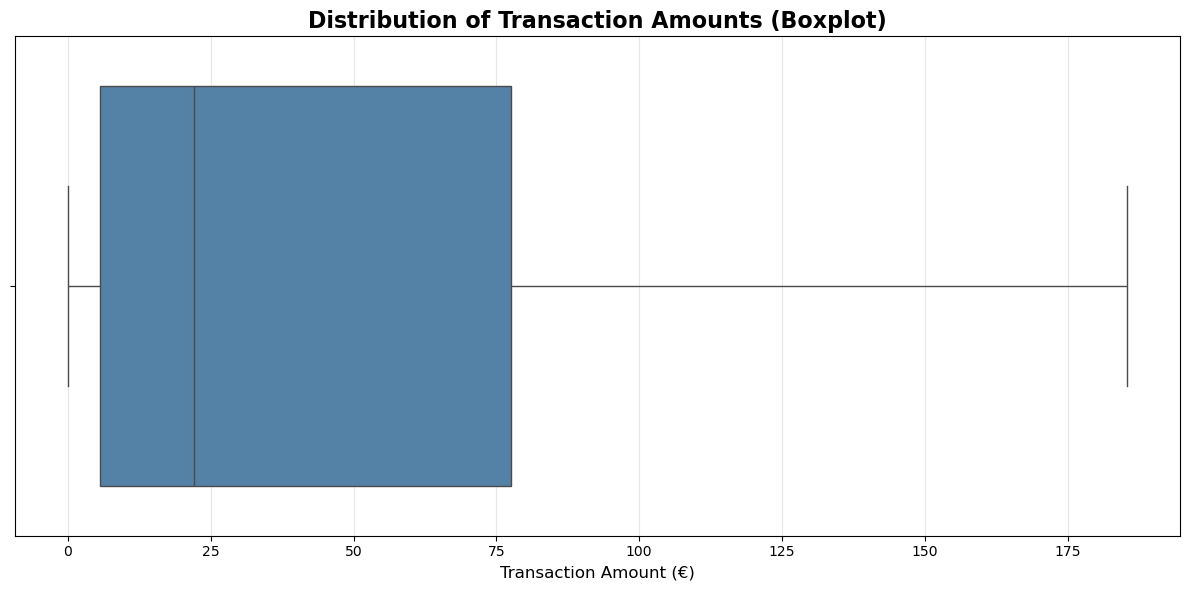

In [4]:
plt.figure(figsize=(12, 6))

sns.boxplot(
    x=df["Amount"],
    color="steelblue",
    showfliers=False
)

plt.title("Distribution of Transaction Amounts (Boxplot)", fontsize=16, weight="bold")
plt.xlabel("Transaction Amount (€)", fontsize=12)

plt.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.show()

## Analysis:

- Transaction amounts are highly right-skewed, with most transactions occurring at lower values and only a small number involving large amounts.
- The histogram illustrates the overall distribution, while the boxplot confirms that the majority of transactions fall within a relatively small range and highlights the presence of extreme values.
- These findings suggest that transaction amount alone is not a reliable indicator of fraud and should be evaluated alongside other transaction characteristics.

## 2. Fraud Distribution

### Business Questions

- How imbalanced is the dataset?
- What percentage of transactions are fraudulent?

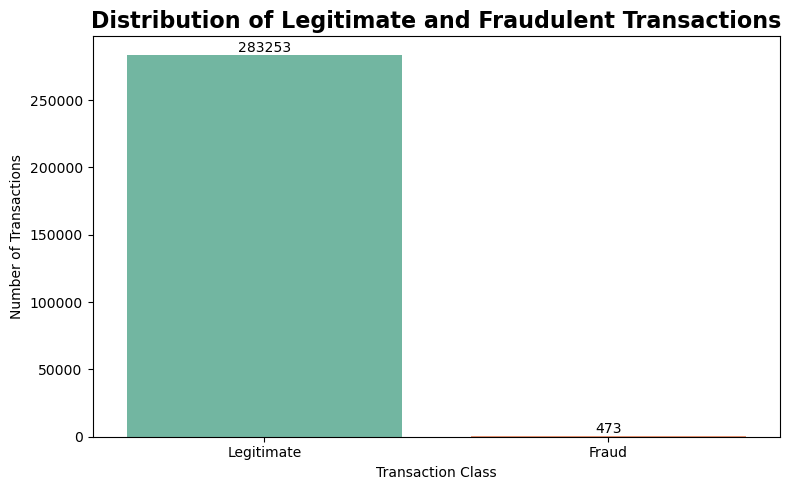

In [5]:
plt.figure(figsize=(8,5))

ax = sns.countplot(
    data=df,
    x="Class",
    hue="Class",
    palette="Set2",
    legend=False
)

plt.title("Distribution of Legitimate and Fraudulent Transactions", fontsize=16, weight="bold")
plt.xlabel("Transaction Class")
plt.ylabel("Number of Transactions")
plt.xticks([0,1], ["Legitimate","Fraud"])

for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()
plt.show()

In [6]:
fraud_percentage = (
    df["Class"]
    .value_counts(normalize=True)
    .mul(100)
    .rename({0:"Legitimate",1:"Fraud"})
    .round(2)
)

fraud_percentage.to_frame(name="Percentage")

,Percentage
Class,
Legitimate,99.83
Fraud,0.17


## Analysis

- The class distribution confirms that the dataset is extremely imbalanced.
- Legitimate transactions account for approximately 99.83% of all transactions, while fraudulent transactions represent only about 0.17%.
- This significant imbalance reflects the rarity of fraud in real-world financial systems and highlights the need for specialized analytical techniques when identifying fraudulent transactions.

## 3. Time Analysis

### Business Questions

- How are transactions distributed over time?
- Does transaction activity remain consistent throughout the dataset?

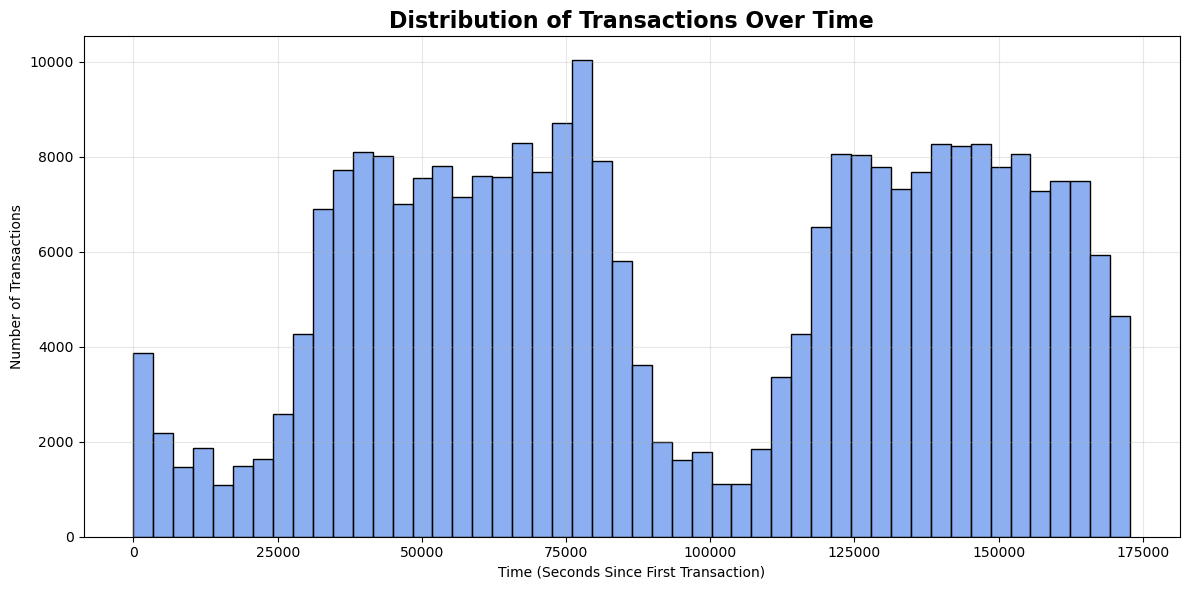

In [7]:
plt.figure(figsize=(12,6))

sns.histplot(
    data=df,
    x="Time",
    bins=50,
    color="cornflowerblue"
)

plt.title("Distribution of Transactions Over Time", fontsize=16, weight="bold")
plt.xlabel("Time (Seconds Since First Transaction)")
plt.ylabel("Number of Transactions")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Analysis

- Transaction activity is distributed throughout the observation period with noticeable fluctuations in frequency.
- Since the `Time` variable represents the elapsed seconds from the first recorded transaction rather than actual timestamps, it cannot be used to infer specific hours or days when fraud is more likely to occur.
- Additional feature engineering will be performed later to derive more meaningful time-based features for analysis.

## 4. Fraud vs Legitimate Transaction Analysis

### Business Questions

- Do fraudulent transactions generally involve different transaction amounts than legitimate transactions?
- How do transaction amount distributions differ between legitimate and fraudulent transactions?

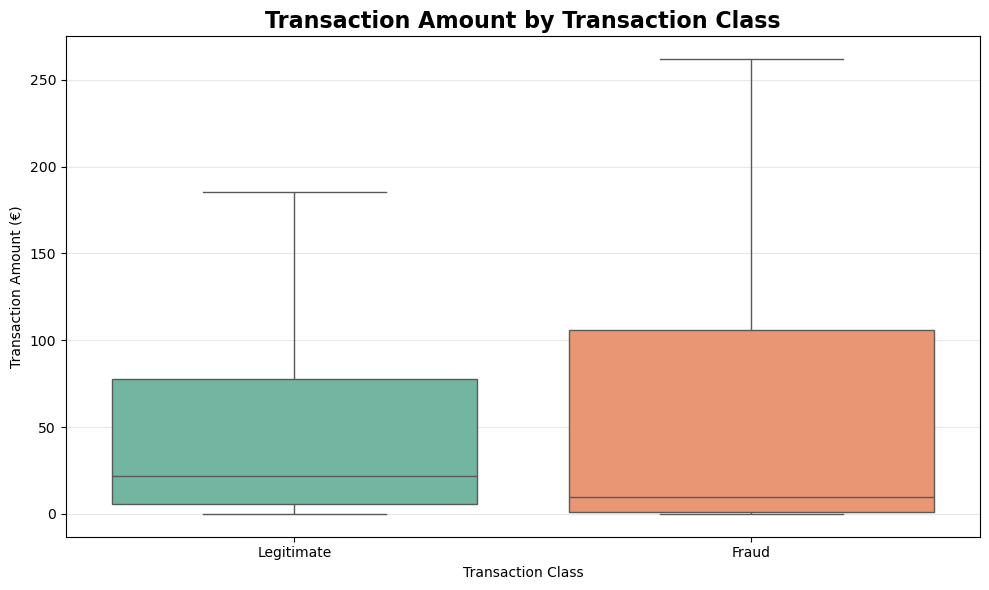

In [8]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=df,
    x="Class",
    y="Amount",
    hue="Class",
    palette="Set2",
    showfliers=False,
    legend=False
)

plt.title("Transaction Amount by Transaction Class", fontsize=16, weight="bold")
plt.xlabel("Transaction Class")
plt.ylabel("Transaction Amount (€)")

plt.xticks([0,1], ["Legitimate", "Fraud"])

plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

## Analysis

- The distribution of transaction amounts differs between legitimate and fraudulent transactions.
- While fraudulent transactions exhibit a lower median transaction amount, they display a wider spread, indicating greater variability in transaction values.
- This suggests that fraud is not limited to high-value transactions and can occur across a broad range of transaction amounts.
- Therefore, transaction amount alone is insufficient for identifying fraudulent activity.

## 5. Correlation Analysis

### Business Questions

- Which features have the strongest relationship with fraudulent transactions?
- Are there any highly correlated features in the dataset?

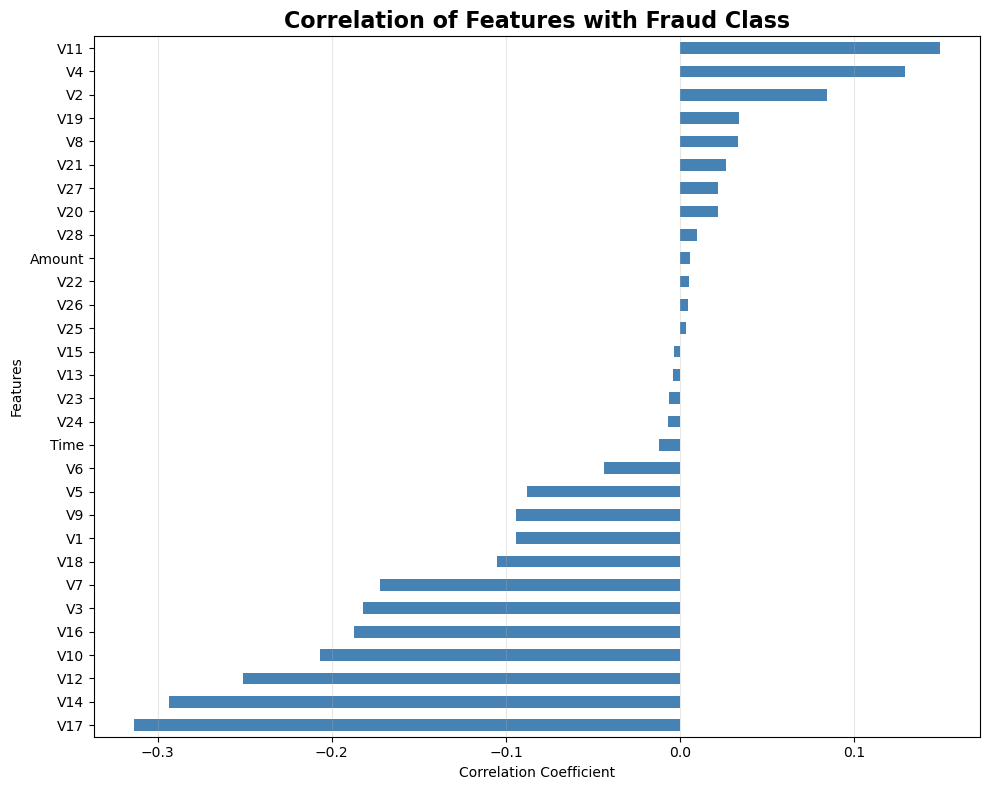

In [9]:
plt.figure(figsize=(10,8))

correlation = (
    df.corr(numeric_only=True)["Class"]
      .drop("Class")
      .sort_values()
)

correlation.plot(kind="barh", color="steelblue")

plt.title("Correlation of Features with Fraud Class", fontsize=16, weight="bold")
plt.xlabel("Correlation Coefficient")
plt.ylabel("Features")

plt.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.show()

## Analysis

- The correlation analysis indicates that the anonymized PCA-transformed features (V1–V28) exhibit the strongest relationships with the target variable (`Class`).
- Features such as V17, V14, and V12 show the strongest negative correlations, while V11, V4, and V2 display the strongest positive correlations with fraudulent transactions.
- In contrast, the `Amount` and `Time` features have very weak linear correlations with fraud, suggesting that they are insufficient as standalone indicators and should be considered alongside other features.

# Key Takeaways

- Transaction amounts are highly right-skewed, with most transactions involving relatively small amounts.
- The dataset is extremely imbalanced, with fraudulent transactions representing a very small proportion of all records.
- Transaction activity is distributed throughout the observation period, although the `Time` feature alone provides limited business insight.
- Fraudulent transactions occur across a wide range of transaction amounts, indicating that amount alone is not a reliable indicator of fraud.
- The anonymized PCA-transformed features (V1–V28) exhibit the strongest linear relationships with fraudulent transactions, while `Time` and `Amount` show relatively weak linear correlations.